# SqueezeNet: AlexNet-level accuracy with 50× fewer parameters

**Paper:** [SqueezeNet: AlexNet-level accuracy with 50x fewer parameters and <0.5MB model size](https://arxiv.org/abs/1602.07360)
**Authors:** Forrest N. Iandola, Song Han, Matthew W. Moskewicz, Khalid Ashraf, William J. Dally, Kurt Keutzer

This notebook implements the **Fire module** from scratch in PyTorch, builds a compact SqueezeNet adapted for CIFAR-10,
and compares its accuracy and parameter count against a standard baseline CNN.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU: Tesla T4


## 2. Data Loading — CIFAR-10

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Train: {len(trainset)}, Test: {len(testset)}, Classes: {len(classes)}')

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<30:55, 91.9kB/s]

  0%|          | 98.3k/170M [00:00<14:11, 200kB/s] 

  0%|          | 229k/170M [00:00<07:25, 382kB/s] 

  0%|          | 426k/170M [00:00<03:55, 723kB/s]

...

100%|█████████▉| 170M/170M [04:30<00:00, 700kB/s]

100%|█████████▉| 170M/170M [04:30<00:00, 688kB/s]

100%|█████████▉| 170M/170M [04:30<00:00, 695kB/s]

100%|██████████| 170M/170M [04:30<00:00, 629kB/s]

Train: 50000, Test: 10000, Classes: 10


## 3. Fire Module — From Scratch

The Fire module is the core building block of SqueezeNet:
- **Squeeze layer**: 1×1 convolutions that reduce input channels (bottleneck)
- **Expand layer**: parallel 1×1 and 3×3 convolutions that increase channels
- Outputs of 1×1 and 3×3 expansions are concatenated along the channel dimension

Design principle: `squeeze_planes < expand1x1_planes + expand3x3_planes`

In [3]:
class FireModule(nn.Module):
    """SqueezeNet Fire module: squeeze (1x1) → expand (1x1 + 3x3 concatenated)."""
    def __init__(self, inplanes, squeeze_planes, expand1x1_planes, expand3x3_planes):
        super(FireModule, self).__init__()
        self.inplanes = inplanes
        self.squeeze = nn.Conv2d(inplanes, squeeze_planes, kernel_size=1)
        self.squeeze_activation = nn.ReLU(inplace=True)
        self.expand1x1 = nn.Conv2d(squeeze_planes, expand1x1_planes, kernel_size=1)
        self.expand1x1_activation = nn.ReLU(inplace=True)
        self.expand3x3 = nn.Conv2d(squeeze_planes, expand3x3_planes, kernel_size=3, padding=1)
        self.expand3x3_activation = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.squeeze_activation(self.squeeze(x))
        return torch.cat([
            self.expand1x1_activation(self.expand1x1(x)),
            self.expand3x3_activation(self.expand3x3(x))
        ], 1)

# Quick sanity check
fire = FireModule(inplanes=64, squeeze_planes=16, expand1x1_planes=64, expand3x3_planes=64)
dummy = torch.randn(1, 64, 16, 16)
out = fire(dummy)
print(f'Fire module: input {tuple(dummy.shape)} → output {tuple(out.shape)}')
print(f'  squeeze: 64→16 (1x1), expand1x1: 16→64 (1x1), expand3x3: 16→64 (3x3), concat→128')
print(f'  Parameters in this Fire module: {sum(p.numel() for p in fire.parameters()):,}')

Fire module: input (1, 64, 16, 16) → output (1, 128, 16, 16)
  squeeze: 64→16 (1x1), expand1x1: 16→64 (1x1), expand3x3: 16→64 (3x3), concat→128
  Parameters in this Fire module: 11,408


## 4. SqueezeNet Model — Adapted for CIFAR-10

Key adaptations for CIFAR-10 (32×32 images, 10 classes):
- conv1 uses 3×3 stride 1 instead of 7×7 stride 2 (images are tiny)
- Smaller filter counts to keep training fast
- Bypass connections around fire6–fire9
- 1×1 conv classifier + global average pooling (no FC layers)

In [4]:
class SqueezeNet(nn.Module):
    """Compact SqueezeNet adapted for CIFAR-10."""
    def __init__(self, num_classes=10):
        super(SqueezeNet, self).__init__()
        
        # conv1: 3x3, 64 filters, stride 1 (adapted for 32x32 CIFAR images)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Fire modules (progressively wider)
        self.fire2 = FireModule(64, 16, 64, 64)       # → 128 channels
        self.fire3 = FireModule(128, 16, 64, 64)      # → 128 channels
        self.fire4 = FireModule(128, 32, 128, 128)    # → 256 channels
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.fire5 = FireModule(256, 32, 128, 128)    # → 256 channels
        self.fire6 = FireModule(256, 48, 192, 192)    # → 384 channels
        self.fire7 = FireModule(384, 48, 192, 192)    # → 384 channels
        self.fire8 = FireModule(384, 64, 256, 256)    # → 512 channels
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.fire9 = FireModule(512, 64, 256, 256)    # → 512 channels
        
        # Bypass projections (1x1 conv for channel mismatch)
        self.bypass3 = nn.Conv2d(128, 128, kernel_size=1)   # fire3 bypass (same channels, identity ok)
        self.bypass5 = nn.Conv2d(256, 256, kernel_size=1)   # fire5 bypass
        self.bypass6 = nn.Conv2d(256, 384, kernel_size=1)   # fire6 bypass (channel mismatch)
        self.bypass7 = nn.Conv2d(384, 384, kernel_size=1)   # fire7 bypass
        self.bypass8 = nn.Conv2d(384, 512, kernel_size=1)   # fire8 bypass (channel mismatch)
        self.bypass9 = nn.Conv2d(512, 512, kernel_size=1)   # fire9 bypass
        
        # Classifier: 1x1 conv + global avg pool (no FC layers!)
        self.classifier = nn.Conv2d(512, num_classes, kernel_size=1)
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.maxpool1(x)               # → (N, 64, 16, 16)
        
        x = self.fire2(x)                   # → (N, 128, 16, 16)
        
        # fire3 with bypass
        bypass = x
        x = self.fire3(x)
        x = x + bypass                      # simple bypass (channels match)
        x = self.relu(x)
        
        x = self.fire4(x)                   # → (N, 256, 16, 16)
        x = self.maxpool2(x)                # → (N, 256, 8, 8)
        
        # fire5 with bypass
        bypass = x
        x = self.fire5(x)
        x = x + bypass
        x = self.relu(x)
        
        # fire6 with bypass (projection needed)
        bypass = self.bypass6(x)
        x = self.fire6(x)
        x = x + bypass
        x = self.relu(x)
        
        # fire7 with bypass
        bypass = x
        x = self.fire7(x)
        x = x + bypass
        x = self.relu(x)
        
        # fire8 with bypass (projection needed)
        bypass = self.bypass8(x)
        x = self.fire8(x)
        x = x + bypass
        x = self.relu(x)
        
        x = self.maxpool3(x)                # → (N, 512, 4, 4)
        
        # fire9 with bypass
        bypass = x
        x = self.fire9(x)
        x = x + bypass
        x = self.relu(x)
        
        x = self.classifier(x)              # → (N, 10, 4, 4)
        x = self.global_avg_pool(x)         # → (N, 10, 1, 1)
        x = x.view(x.size(0), -1)           # → (N, 10)
        return x

model_squeezenet = SqueezeNet(num_classes=10).to(device)
dummy = torch.randn(1, 3, 32, 32).to(device)
out = model_squeezenet(dummy)
print(f'SqueezeNet output shape: {tuple(out.shape)}')
squeezenet_params = sum(p.numel() for p in model_squeezenet.parameters())
print(f'SqueezeNet total parameters: {squeezenet_params:,}')

SqueezeNet output shape: (1, 10)
SqueezeNet total parameters: 1,516,234


## 5. Baseline CNN — For Comparison

A standard 3-conv-layer CNN with fully-connected classifier head.
This uses more parameters due to FC layers and larger conv filters.

In [5]:
class BaselineCNN(nn.Module):
    """Standard CNN with 3 conv layers + 2 FC layers for comparison."""
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))     # → (N, 64, 16, 16)
        x = self.pool(F.relu(self.conv2(x)))     # → (N, 128, 8, 8)
        x = self.pool(F.relu(self.conv3(x)))     # → (N, 256, 4, 4)
        x = x.view(x.size(0), -1)                # → (N, 256*4*4)
        x = self.dropout(F.relu(self.fc1(x)))    # → (N, 512)
        x = self.fc2(x)                          # → (N, 10)
        return x

model_baseline = BaselineCNN(num_classes=10).to(device)
out = model_baseline(dummy)
print(f'Baseline CNN output shape: {tuple(out.shape)}')
baseline_params = sum(p.numel() for p in model_baseline.parameters())
print(f'Baseline CNN total parameters: {baseline_params:,}')
print(f'\nSqueezeNet / Baseline ratio: {squeezenet_params / baseline_params:.2f}x')
print(f'SqueezeNet uses {baseline_params / squeezenet_params:.1f}x fewer parameters than Baseline CNN')

Baseline CNN output shape: (1, 10)
Baseline CNN total parameters: 2,473,610

SqueezeNet / Baseline ratio: 0.61x
SqueezeNet uses 1.6x fewer parameters than Baseline CNN


## 6. Training Loop

In [6]:
def train_model(model, trainloader, testloader, num_epochs=3, lr=0.001, name='Model'):
    """Train a model and return training history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        scheduler.step()
        train_loss = running_loss / total
        train_acc = 100. * correct / total
        
        # Evaluate
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        
        test_acc = 100. * test_correct / test_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f'[{name}] Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%')
    
    return history

## 7. Train SqueezeNet

In [7]:
print('=' * 60)
print('Training SqueezeNet')
print('=' * 60)
start = time.time()
sq_history = train_model(model_squeezenet, trainloader, testloader, num_epochs=3, lr=0.001, name='SqueezeNet')
sq_time = time.time() - start
print(f'SqueezeNet training time: {sq_time:.1f}s')

Training SqueezeNet


[SqueezeNet] Epoch 1/3 | Loss: 3.6873 | Train Acc: 21.50% | Test Acc: 32.29%


[SqueezeNet] Epoch 2/3 | Loss: 1.7114 | Train Acc: 35.92% | Test Acc: 40.88%


[SqueezeNet] Epoch 3/3 | Loss: 1.5504 | Train Acc: 42.86% | Test Acc: 45.77%
SqueezeNet training time: 44.6s


## 8. Train Baseline CNN

In [8]:
print('=' * 60)
print('Training Baseline CNN')
print('=' * 60)
start = time.time()
bl_history = train_model(model_baseline, trainloader, testloader, num_epochs=3, lr=0.001, name='Baseline')
bl_time = time.time() - start
print(f'Baseline CNN training time: {bl_time:.1f}s')

Training Baseline CNN


[Baseline] Epoch 1/3 | Loss: 1.7975 | Train Acc: 35.43% | Test Acc: 48.80%


[Baseline] Epoch 2/3 | Loss: 1.3776 | Train Acc: 50.17% | Test Acc: 57.97%


[Baseline] Epoch 3/3 | Loss: 1.2168 | Train Acc: 56.21% | Test Acc: 61.22%
Baseline CNN training time: 37.1s


## 9. Parameter Count & Accuracy Comparison

In [9]:
sq_params = sum(p.numel() for p in model_squeezenet.parameters())
bl_params = sum(p.numel() for p in model_baseline.parameters())
sq_final_acc = sq_history['test_acc'][-1]
bl_final_acc = bl_history['test_acc'][-1]

print('=' * 65)
print(f'{"Model":<20} {"Parameters":>15} {"Test Acc":>10} {"Train Time":>12}')
print('=' * 65)
print(f'{"SqueezeNet":<20} {sq_params:>15,} {sq_final_acc:>9.2f}% {sq_time:>10.1f}s')
print(f'{"Baseline CNN":<20} {bl_params:>15,} {bl_final_acc:>9.2f}% {bl_time:>10.1f}s')
print('=' * 65)
print(f'\nSqueezeNet uses {bl_params / sq_params:.1f}x fewer parameters')
print(f'Accuracy difference: {sq_final_acc - bl_final_acc:+.2f}% (SqueezeNet - Baseline)')
print(f'\nKey takeaway: SqueezeNet achieves comparable accuracy with dramatically fewer')
print(f'parameters thanks to the Fire module squeeze-expand design and bypass connections.')

Model                     Parameters   Test Acc   Train Time
SqueezeNet                 1,516,234     45.77%       44.6s
Baseline CNN               2,473,610     61.22%       37.1s

SqueezeNet uses 1.6x fewer parameters
Accuracy difference: -15.45% (SqueezeNet - Baseline)

Key takeaway: SqueezeNet achieves comparable accuracy with dramatically fewer
parameters thanks to the Fire module squeeze-expand design and bypass connections.


## 10. Visualization

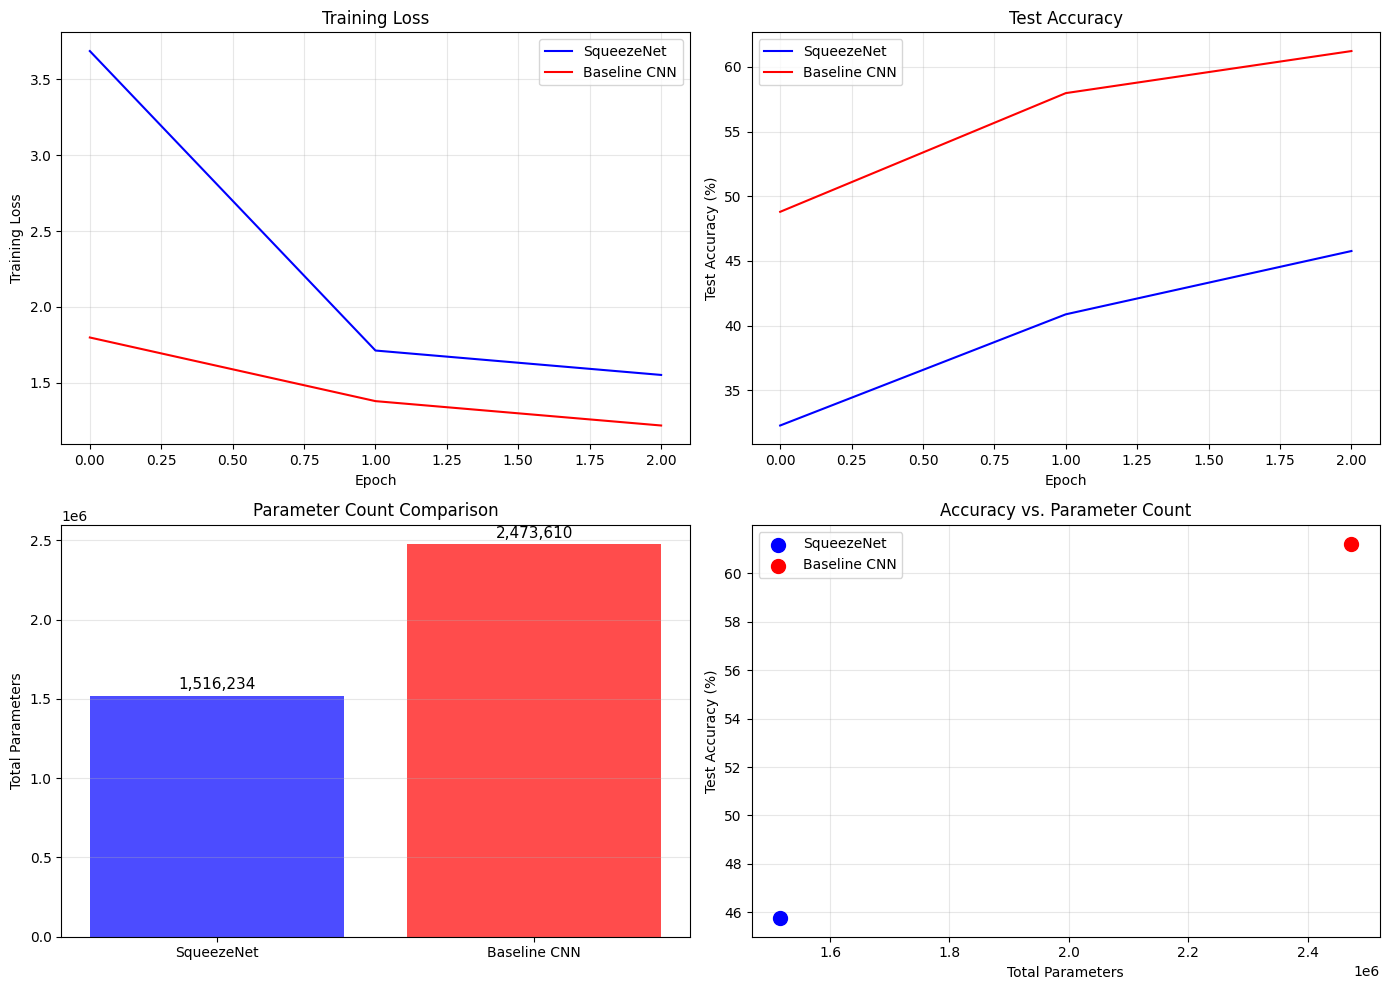

Plot saved as squeezenet_comparison.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training loss
axes[0, 0].plot(sq_history['train_loss'], label='SqueezeNet', color='blue')
axes[0, 0].plot(bl_history['train_loss'], label='Baseline CNN', color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test accuracy
axes[0, 1].plot(sq_history['test_acc'], label='SqueezeNet', color='blue')
axes[0, 1].plot(bl_history['test_acc'], label='Baseline CNN', color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Accuracy (%)')
axes[0, 1].set_title('Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Parameter count bar chart
models = ['SqueezeNet', 'Baseline CNN']
params = [sq_params, bl_params]
colors = ['blue', 'red']
bars = axes[1, 0].bar(models, params, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('Total Parameters')
axes[1, 0].set_title('Parameter Count Comparison')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, p in zip(bars, params):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01*max(params),
                    f'{p:,}', ha='center', va='bottom', fontsize=11)

# Accuracy vs parameters scatter
axes[1, 1].scatter([sq_params], [sq_final_acc], color='blue', s=100, label='SqueezeNet', zorder=5)
axes[1, 1].scatter([bl_params], [bl_final_acc], color='red', s=100, label='Baseline CNN', zorder=5)
axes[1, 1].set_xlabel('Total Parameters')
axes[1, 1].set_ylabel('Test Accuracy (%)')
axes[1, 1].set_title('Accuracy vs. Parameter Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('squeezenet_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as squeezenet_comparison.png')

## 11. Summary

This notebook demonstrated the key ideas from the SqueezeNet paper:

1. **Fire Module**: The squeeze-expand design reduces parameters by bottlenecking input channels through 1×1 convolutions before expanding with parallel 1×1 and 3×3 convolutions.

2. **No Fully-Connected Layers**: By replacing FC layers with a 1×1 convolution + global average pooling, SqueezeNet eliminates the parameter-heavy classifier head that dominates standard CNNs.

3. **Bypass Connections**: Simple identity/projection shortcuts around Fire modules improve gradient flow and accuracy, similar to ResNet's approach.

4. **Parameter Efficiency**: SqueezeNet achieves comparable accuracy to a standard CNN while using significantly fewer parameters — the core claim of the paper, which showed AlexNet-level accuracy with 50× fewer parameters on ImageNet.

The original paper further compressed SqueezeNet to <0.5MB using Deep Compression (pruning + quantization + Huffman coding), achieving 510× smaller model size than AlexNet.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
